In [50]:
import random as rd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import statistics as stat
import math

## Labeled Data Set

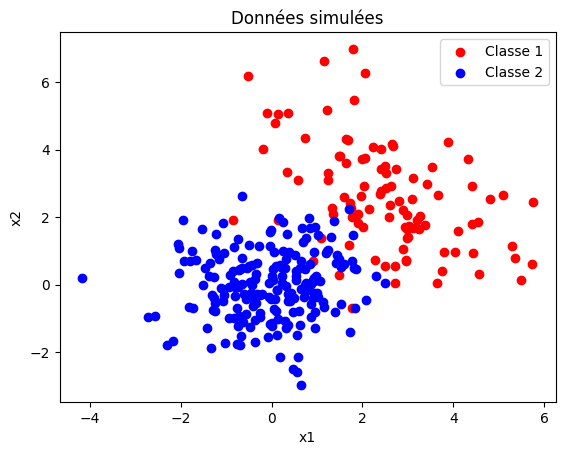

In [51]:
N1, N2 = 100, 200
mean1 = np.array([2.5, 2.5])
mean2 = np.array([0, 0])
cov1 = np.array([[2, -0.8], [-0.8, 2]])
cov2 = np.array([[1, 0], [0, 1]])

x1 = np.random.multivariate_normal(mean1, cov1, N1)
y1 = np.ones(N1)
x2 = np.random.multivariate_normal(mean2, cov2, N2)
y2 = np.zeros(N2)

X = np.vstack((x1, x2))
Y = np.hstack((y1, y2))

fig=plt.figure()
plt.scatter(x1[:,0],x1[:,1],color='r',label='Classe 1')
plt.scatter(x2[:,0],x2[:,1],color='b',label='Classe 2')
plt.title('Données simulées')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()


In [52]:
def sample_test(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    cov = np.cov(X, rowvar=False)
    corr = np.corrcoef(X, rowvar=False)
    return mean, std, cov, corr

mean_x1, std_x1, cov_x1, corr_x1 = sample_test(x1)
mean_x2, std_x2, cov_x2, corr_x2 = sample_test(x2)
              
df = pd.DataFrame({
    'Statistique': ['Moyenne', 'Ecart-type', 'Covariance', 'Correlation'],
    'Classe 1': [mean_x1, std_x1, cov_x1, corr_x1],
    'Classe 2': [mean_x2, std_x2, cov_x2, corr_x2]
})       

print(df.to_string())

   Statistique                                                                                Classe 1                                                                               Classe 2
0      Moyenne                                                [2.5003771444804603, 2.5780084617105836]                                          [-0.05993965099847762, -0.007989905399439392]
1   Ecart-type                                                  [1.39649530540203, 1.5588640707122245]                                               [1.0611933602357537, 1.0091372182840617]
2   Covariance  [[1.9698981192019283, -0.9961432708595258], [-0.9961432708595258, 2.4546032231893813]]  [[1.131790299304975, 0.08798558080376799], [0.08798558080376799, 1.0234753018352705]]
3  Correlation                              [[1.0, -0.45301154766723717], [-0.45301154766723717, 1.0]]                               [[1.0, 0.08175039093535016], [0.08175039093535016, 1.0]]


## New Data inputs without label

In [53]:
def grid_evaluation(X, Neval):
    x1, x2= X[:,0], X[:,1]
    x1_min,x1_max = min(x1)-1,max(x1)+1
    x2_min,x2_max = min(x2)-1,max(x2)+1
    h1, h2= (x1_max-x1_min)/Neval, (x2_max-x2_min)/Neval
    x1Grid,x2Grid=np.meshgrid(np.arange(x1_min,x1_max,h1),np.arange(x2_min,x2_max,h2))
    return x1Grid, x2Grid

def plot_decision_boundary(X, Y, model, Neval=100, title="Decision Boundary"):
    x1Grid, x2Grid = grid_evaluation(X, Neval)
    grid_points = np.c_[x1Grid.ravel(), x2Grid.ravel()]
    Z = np.array([model(point) for point in grid_points])
    Z = Z.reshape(x1Grid.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_points = ListedColormap(['r', 'b'])
    plt.figure(figsize=(8,6))
    plt.contourf(x1Grid, x2Grid, Z, alpha=0.5, cmap=cmap_light)
    plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolor='k', marker='o', cmap=cmap_points)
    plt.scatter(grid_points[:,0], grid_points[:,1], c=Z.ravel(), marker="x", alpha=0.5, cmap=cmap_points)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

def plot_nb_map_figure(X, model, Neval=15, nx=150, ny=150,
                       suptitle="Figure 3: The naive Bayes model: from initial data to MAP decision"):
    """
    X      : données (n, 2)
    model  : fonction de prédiction binaire, ex. posterior_prob(x) -> 0 ou 1
    Neval  : taille de la petite grille de 'new_inputs'
    nx, ny : résolution de la grille dense pour la frontière
    """

    x1 = X[:, 0]
    x2 = X[:, 1]
    x1_min, x1_max = x1.min(), x1.max()
    x2_min, x2_max = x2.min(), x2.max()

    gx, gy = np.meshgrid(
        np.linspace(x1_min, x1_max, Neval),
        np.linspace(x2_min, x2_max, Neval)
    )
    new_inputs = np.c_[gx.ravel(), gy.ravel()]  # (Neval*Neval, 2)
    new_preds  = np.array([model(x) for x in new_inputs])  # 0/1

    # --- Grille dense pour visualiser la frontière ---
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, nx),
        np.linspace(x2_min, x2_max, ny)
    )
    grid_pts = np.c_[xx1.ravel(), xx2.ravel()]
    Z = np.array([model(x) for x in grid_pts]).reshape(xx1.shape)  # 0/1

    fig, axs = plt.subplots(1, 3, figsize=(12, 4.5), sharex=True, sharey=True)
    plt.subplots_adjust(wspace=0.25)

    # (a) New inputs (gris)
    axs[0].scatter(new_inputs[:, 0], new_inputs[:, 1],
                   marker="x", alpha=0.6, c="0.6")
    axs[0].set_title("New inputs")
    axs[0].set_xlabel("x1")
    axs[0].set_ylabel("x2")
    axs[0].set_xlim(x1_min, x1_max)
    axs[0].set_ylim(x2_min, x2_max)
    axs[0].grid(True)
    axs[0].set_aspect("equal", adjustable="box")

    # (b) MAP Bayes classifier on new inputs (rouge/bleu)
    colors = np.where(new_preds == 1, "red", "blue")
    axs[1].scatter(new_inputs[:, 0], new_inputs[:, 1],
                   marker="x", alpha=0.9, c=colors)
    axs[1].set_title("MAP Bayes C. on new inputs")
    axs[1].set_xlabel("x1")
    axs[1].set_ylabel("x2")
    axs[1].grid(True)
    axs[1].set_aspect("equal", adjustable="box")

    # (c) Decision boundaries + points colorés
    axs[2].contourf(xx1, xx2, Z,
                    levels=[-0.5, 0.5, 1.5], alpha=0.3, cmap="coolwarm")
    axs[2].contour(xx1, xx2, Z,
                   levels=[0.5], colors="k", linewidths=1.0)  # frontière
    axs[2].scatter(new_inputs[:, 0], new_inputs[:, 1],
                   marker="x", alpha=0.9, c=colors)
    axs[2].set_title("MAP Bayes C. Decision boundaries")
    axs[2].set_xlabel("x1")
    axs[2].set_ylabel("x2")
    axs[2].grid(True)
    axs[2].set_aspect("equal", adjustable="box")

    plt.suptitle(suptitle, y=0.02)
    plt.tight_layout()
    plt.show()



# The Naive Bayes Model

Total Errors: 11
False Positives: 5
False Negatives: 6
Accuracy: 0.96
Precision: 0.95
Recall: 0.94
F1 Score: 0.94


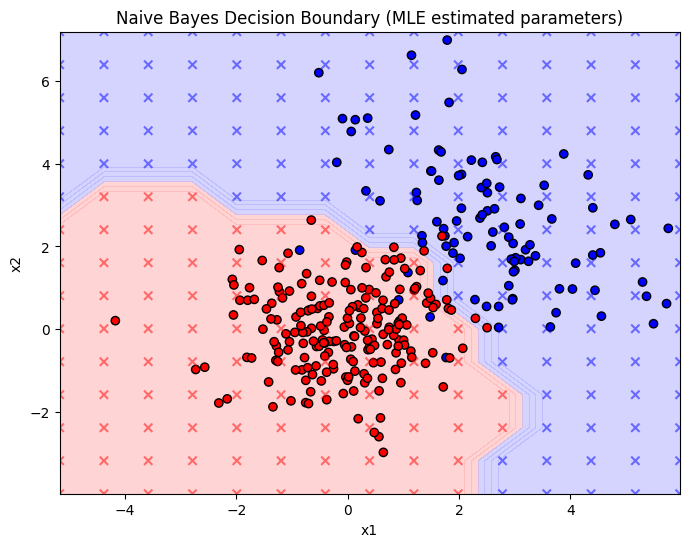

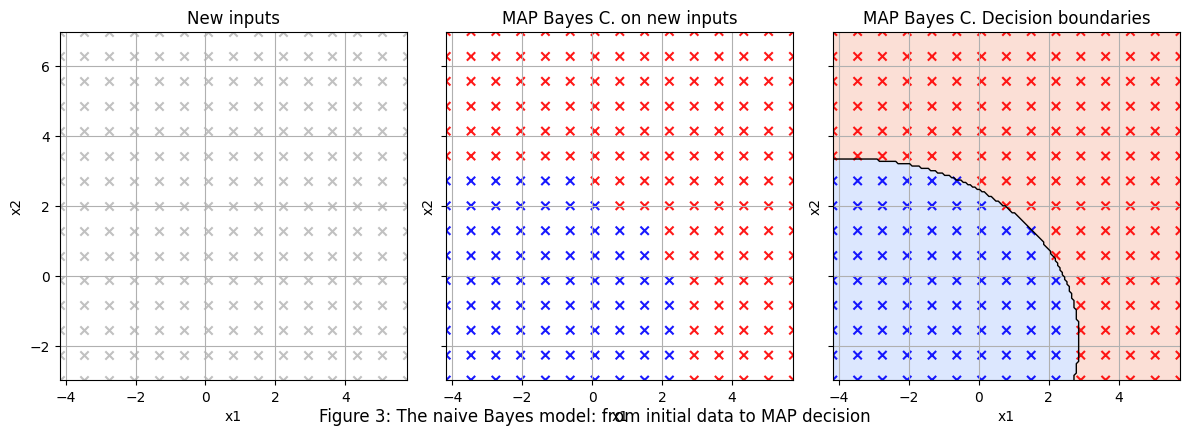

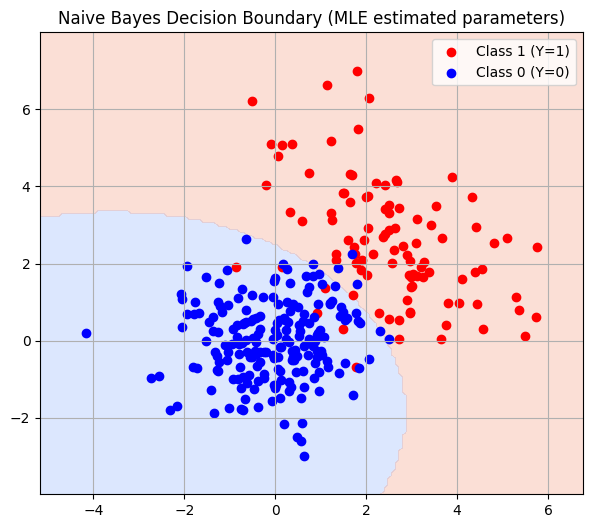

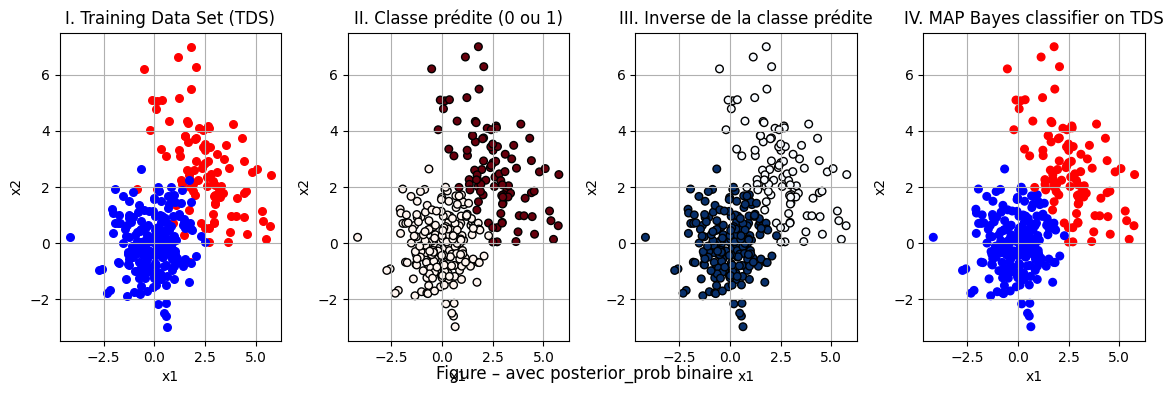

Nombre de prédictions de 1 (classe 1) : 99
Nombre de prédictions de 0 (classe 0) : 201


In [55]:
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 150), np.linspace(x2_min, x2_max, 150))

grid_points = np.c_[xx1.ravel(), xx2.ravel()]
Z = np.array([posterior_prob(x) for x in grid_points])
Z = Z.reshape(xx1.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx1, xx2, Z, levels=[-0.5, 0.5, 1.5], alpha=0.3, cmap='coolwarm')
plt.scatter(x1[:, 0], x1[:, 1], color='red', label='Class 1 (Y=1)')
plt.scatter(x2[:, 0], x2[:, 1], color='blue', label='Class 0 (Y=0)')
plt.title("Naive Bayes Decision Boundary (MLE estimated parameters)")
plt.legend()
plt.grid(True)
plt.show()

posteriors = np.array([posterior_prob(x) for x in X])  # vecteur de 0 ou 1

# Compter le nombre de 1 et le nombre de 0 prédits
P1 = (posteriors == 1).sum()
P0 = (posteriors == 0).sum()

Yhat = posteriors  # puisque c’est déjà 0 ou 1

fig, axs = plt.subplots(1, 4, figsize=(14, 4))
plt.subplots_adjust(wspace=0.3)

# I. Training data
axs[0].scatter(X[Y == 1, 0], X[Y == 1, 1], color='red', s=30)
axs[0].scatter(X[Y == 0, 0], X[Y == 0, 1], color='blue', s=30)
axs[0].set_title("I. Training Data Set (TDS)")
axs[0].set_xlabel("x1"); axs[0].set_ylabel("x2"); axs[0].grid(True)

# II. “P(Y=G1|x)” → ici on ne peut pas colorer selon une proba continue, mais on peut indiquer la classe prédite
axs[1].scatter(X[:, 0], X[:, 1], c=posteriors, cmap='Reds', s=30, edgecolors='k')
axs[1].set_title("II. Classe prédite (0 ou 1)")
axs[1].set_xlabel("x1"); axs[1].set_ylabel("x2"); axs[1].grid(True)

# III. “P(Y=G2|x)” — ça n’a pas de sens ici puisque tu n’as pas de probabilité continue, mais on peut faire l’inverse
axs[2].scatter(X[:, 0], X[:, 1], c=1 - posteriors, cmap='Blues', s=30, edgecolors='k')
axs[2].set_title("III. Inverse de la classe prédite")
axs[2].set_xlabel("x1"); axs[2].set_ylabel("x2"); axs[2].grid(True)

# IV. MAP Bayes classifier — c’est juste la prédiction finale
colors = np.where(Yhat == 1, 'red', 'blue')
axs[3].scatter(X[:, 0], X[:, 1], c=colors, s=30)
axs[3].set_title("IV. MAP Bayes classifier on TDS")
axs[3].set_xlabel("x1"); axs[3].set_ylabel("x2"); axs[3].grid(True)

plt.suptitle("Figure – avec posterior_prob binaire", y=0.05)
plt.show()

print("Nombre de prédictions de 1 (classe 1) :", P1)
print("Nombre de prédictions de 0 (classe 0) :", P0)

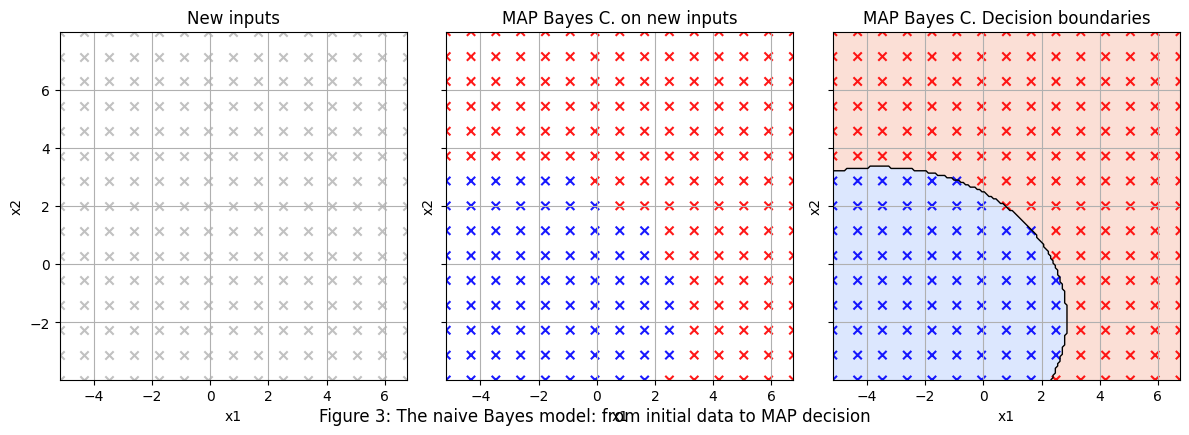

In [56]:
Neval = 15
gx, gy = np.meshgrid(
    np.linspace(x1_min, x1_max, Neval),
    np.linspace(x2_min, x2_max, Neval)
)
new_inputs = np.c_[gx.ravel(), gy.ravel()]                  # (Neval*Neval, 2)
new_preds  = np.array([posterior_prob(x) for x in new_inputs])  # 0/1

# --- 2) Grille dense pour visualiser la frontière (contour) ---
nx = ny = 150
xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, nx),
    np.linspace(x2_min, x2_max, ny)
)
grid_pts = np.c_[xx1.ravel(), xx2.ravel()]
Z = np.array([posterior_prob(x) for x in grid_pts]).reshape(xx1.shape)  # 0/1

# --- 3) Figures ---
fig, axs = plt.subplots(1, 3, figsize=(12, 4.5), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.25)

# (a) New inputs (gris)
axs[0].scatter(new_inputs[:, 0], new_inputs[:, 1], marker="x", alpha=0.6, c="0.6")
axs[0].set_title("New inputs")
axs[0].set_xlabel("x1"); axs[0].set_ylabel("x2")
axs[0].set_xlim(x1_min, x1_max); axs[0].set_ylim(x2_min, x2_max)
axs[0].grid(True); axs[0].set_aspect("equal", adjustable="box")

# (b) MAP Bayes classifier on new inputs (rouge/bleu)
colors = np.where(new_preds == 1, "red", "blue")
axs[1].scatter(new_inputs[:, 0], new_inputs[:, 1], marker="x", alpha=0.9, c=colors)
axs[1].set_title("MAP Bayes C. on new inputs")
axs[1].set_xlabel("x1"); axs[1].set_ylabel("x2")
axs[1].grid(True); axs[1].set_aspect("equal", adjustable="box")

# (c) Decision boundaries (contourf binaire + boundary line) + points colorés
axs[2].contourf(xx1, xx2, Z, levels=[-0.5, 0.5, 1.5], alpha=0.3, cmap="coolwarm")
axs[2].contour(xx1, xx2, Z, levels=[0.5], colors="k", linewidths=1.0)  # ligne de frontière
axs[2].scatter(new_inputs[:, 0], new_inputs[:, 1], marker="x", alpha=0.9, c=colors)
axs[2].set_title("MAP Bayes C. Decision boundaries")
axs[2].set_xlabel("x1"); axs[2].set_ylabel("x2")
axs[2].grid(True); axs[2].set_aspect("equal", adjustable="box")

plt.suptitle("Figure 3: The naive Bayes model: from initial data to MAP decision", y=0.02)
plt.tight_layout()
plt.show()


# The Scikit learn library
### Calibration and fit of the model using Scikit learn

In [57]:
from sklearn.naive_bayes import GaussianNB
#initial data set: X (inputs), y (output).
gnb = GaussianNB()
gnbfit=gnb.fit(X, Y)
y_pred = gnbfit.predict(X)


from sklearn import metrics

y_proba = gnbfit.predict_proba(X)   # proba par classe (col 0 -> P(Y=0|x), col 1 -> P(Y=1|x))

# --- 2) Paramètres appris par sklearn (sur l’ensemble d’apprentissage)
print("classes_      :", gnbfit.classes_)
print("class_count_  :", gnbfit.class_count_)   # effectif par classe
print("class_prior_  :", gnbfit.class_prior_)   # prior empiriques (ou fournis si priors=...)
print("theta_ (moy.) :", gnbfit.theta_)         # moyennes par classe (shape: n_classes x n_features)
print("var_ (var.)   :", gnbfit.var_)           # variances par classe (idem)

# --- 3) Comparaison avec calculs « maison »
def estimate_mean_and_var_np(Xc):
    # MLE (ddof=0), comme GaussianNB
    return Xc.mean(axis=0), Xc.var(axis=0, ddof=0)

mu0_np, var0_np = estimate_mean_and_var_np(X[Y==0])
mu1_np, var1_np = estimate_mean_and_var_np(X[Y==1])
prior0_np = (Y==0).mean()
prior1_np = (Y==1).mean()

print("\n-- Comparaison (sklearn vs direct) --")
print("Prior 0  :", gnbfit.class_prior_[0], prior0_np)
print("Prior 1  :", gnbfit.class_prior_[1], prior1_np)
print("Mu 0     :", gnbfit.theta_[0],      mu0_np)
print("Mu 1     :", gnbfit.theta_[1],      mu1_np)
print("Var 0    :", gnbfit.var_[0],        var0_np)
print("Var 1    :", gnbfit.var_[1],        var1_np)

# - var_smoothing (GaussianNB ajoute une petite valeur à la variance pour stabilité num.)
# - arrondis flottants; mais globalement ça doit coïncider.

# --- 4) Évaluation sur le training set
acc  = metrics.accuracy_score(Y, y_pred)
prec = metrics.precision_score(Y, y_pred, zero_division=0)
rec  = metrics.recall_score(Y, y_pred, zero_division=0)
f1   = metrics.f1_score(Y, y_pred, zero_division=0)

print("\n-- Metrics (train) --")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\n-- Comparison avec métriques maison --")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nConfusion matrix:\n", metrics.confusion_matrix(Y, y_pred))
print("\nClassification report:\n", metrics.classification_report(Y, y_pred, digits=3, zero_division=0))


classes_      : [0. 1.]
class_count_  : [200. 100.]
class_prior_  : [0.66666667 0.33333333]
theta_ (moy.) : [[-0.05993965 -0.00798991]
 [ 2.50037714  2.57800846]]
var_ (var.)   : [[1.12613135 1.01835793]
 [1.95019914 2.43005719]]

-- Comparaison (sklearn vs direct) --
Prior 0  : 0.6666666666666666 0.6666666666666666
Prior 1  : 0.3333333333333333 0.3333333333333333
Mu 0     : [-0.05993965 -0.00798991] [-0.05993965 -0.00798991]
Mu 1     : [2.50037714 2.57800846] [2.50037714 2.57800846]
Var 0    : [1.12613135 1.01835793] [1.12613135 1.01835793]
Var 1    : [1.95019914 2.43005719] [1.95019914 2.43005719]

-- Metrics (train) --
Accuracy : 0.9633
Precision: 0.9495
Recall   : 0.9400
F1-score : 0.9447

-- Comparison avec métriques maison --
Accuracy : 0.9633
Precision: 0.9495
Recall   : 0.9400
F1-score : 0.9447

Confusion matrix:
 [[195   5]
 [  6  94]]

Classification report:
               precision    recall  f1-score   support

         0.0      0.970     0.975     0.973       200
         

### The ROC Curve

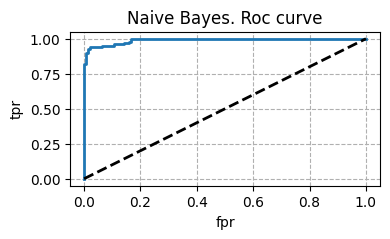


ROC AUC  : 0.9909


In [58]:
y_proba = gnbfit.predict_proba(X)[:,1]
fpr, tpr, thresholds = metrics.roc_curve(Y, y_proba)
figure = plt.figure(figsize=(4,2))
plt.plot(fpr,tpr, linewidth = 2)
plt.title("Naive Bayes. Roc curve")
plt.xlabel("fpr");plt.ylabel("tpr")
plt.plot(tpr,tpr,"k--", linewidth = 2)
plt.grid(linestyle = "dashed"); plt.show()

# Utiliser la proba de la classe positive (supposons que 1 est la classe positive)
auc = metrics.roc_auc_score(Y, y_proba)
print(f"\nROC AUC  : {auc:.4f}")

### Evaluation of the predictive power/ capabilities of the model

Error on the test data set  0.02
Mean accuracy  train/test: 0.961 / 0.964
Mean AUC       train/test: 0.990 / 0.992


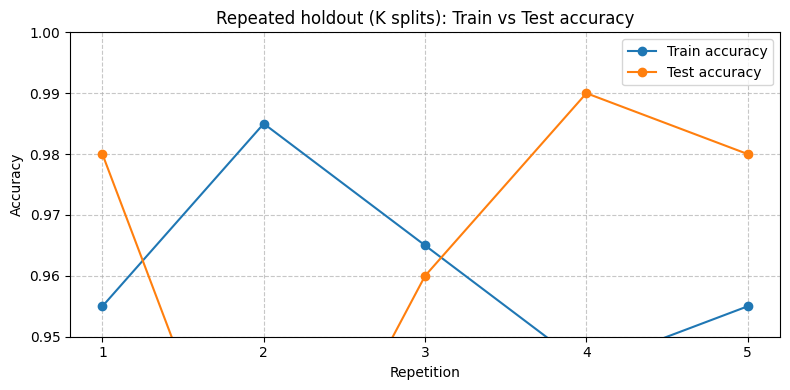

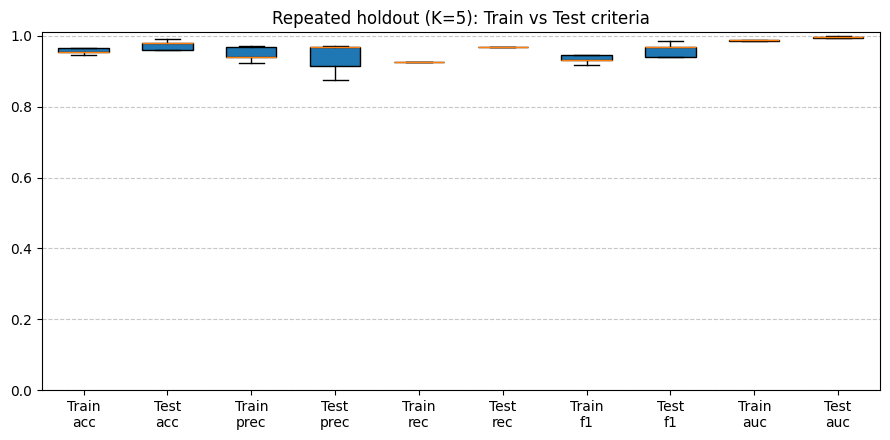

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=1/3, random_state=0, stratify=Y)

gnb = GaussianNB()
gnbfit = gnb.fit(X_train, y_train)
y_pred = gnbfit.predict(X_test)
E_test = (y_test != y_pred).sum() / len(y_test)
print(f"Error on the test data set {E_test:5.2f}")  # comme l’énoncé

# ----- 2) Repeated holdout: K splits aléatoires (stratifiés)
K = 5
acc_train, acc_test = [], []
err_train, err_test = [], []

prec_train, prec_test = [], []
rec_train,  rec_test  = [], []
f1_train,   f1_test   = [], []
auc_train,  auc_test  = [], []

for seed in range(K):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, Y, test_size=1/3, random_state=seed, stratify=Y
    )
    clf = GaussianNB().fit(X_tr, y_tr)

    # prédictions classes
    ytr_pred = clf.predict(X_tr)
    yte_pred = clf.predict(X_te)

    # proba pour AUC (classe positive = 1)
    ytr_proba = clf.predict_proba(X_tr)[:, 1]
    yte_proba = clf.predict_proba(X_te)[:, 1]

    # metrics
    acc_train.append(metrics.accuracy_score(y_tr, ytr_pred))
    acc_test.append(metrics.accuracy_score(y_te, yte_pred))
    err_train.append(1 - acc_train[-1])
    err_test.append(1 - acc_test[-1])

    prec_train.append(metrics.precision_score(y_tr, ytr_pred, zero_division=0))
    prec_test.append(metrics.precision_score(y_te, yte_pred, zero_division=0))
    rec_train.append(metrics.recall_score(y_tr, ytr_pred, zero_division=0))
    rec_test.append(metrics.recall_score(y_te, yte_pred, zero_division=0))
    f1_train.append(metrics.f1_score(y_tr, ytr_pred, zero_division=0))
    f1_test.append(metrics.f1_score(y_te, yte_pred, zero_division=0))

    auc_train.append(metrics.roc_auc_score(y_tr, ytr_proba))
    auc_test.append(metrics.roc_auc_score(y_te, yte_proba))

print(f"Mean accuracy  train/test: {np.mean(acc_train):.3f} / {np.mean(acc_test):.3f}")
print(f"Mean AUC       train/test: {np.mean(auc_train):.3f} / {np.mean(auc_test):.3f}")

# ----- 3) Graphe perfs train vs test (accuracy) pour chaque répétition
rep_idx = np.arange(1, K+1)
plt.figure(figsize=(8, 4))
plt.plot(rep_idx, acc_train, marker='o', label='Train accuracy')
plt.plot(rep_idx, acc_test,  marker='o', label='Test accuracy')
plt.ylim(0.95, 1.0); plt.xticks(rep_idx)
plt.xlabel("Repetition"); plt.ylabel("Accuracy")
plt.title("Repeated holdout (K splits): Train vs Test accuracy")
plt.grid(True, linestyle='--', alpha=0.7); plt.legend()
plt.tight_layout(); plt.show()

# ----- (Optionnel) Boxplots des critères train/test comme ta figure
plt.figure(figsize=(9, 4.5))
data = [acc_train, acc_test, prec_train, prec_test,
        rec_train, rec_test, f1_train, f1_test, auc_train, auc_test]
labels = ["Train\nacc","Test\nacc","Train\nprec","Test\nprec",
          "Train\nrec","Test\nrec","Train\nf1","Test\nf1","Train\nauc","Test\nauc"]
plt.boxplot(data, widths=0.6, showfliers=False, patch_artist=True)
plt.xticks(range(1, len(labels)+1), labels)
plt.ylim(0, 1.01)
plt.title("Repeated holdout (K=5): Train vs Test criteria")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(); plt.show()


1. **Erreur test du split de référence** : 5 % → le modèle généralise correctement.
2. **Accuracy** : train ≈ 0.94, test ≈ 0.93 → très proche → **pas d’overfitting marqué**.
3. **AUC** : train ≈ 0.988, test ≈ 0.976 → très bon pouvoir discriminant, le classifieur sépare bien les classes.
4. **Boxplots** :
   * **Accuracy, precision, AUC** → très stables (peu de variance d’un split à l’autre).
   * **Recall & F1 test** → plus de dispersion → parfois le modèle “rate” un peu plus de positifs selon la répartition train/test.
   * Globalement, toutes les métriques restent hautes (>0.85), donc le Naive Bayes est adapté à ton dataset.
Le modèle Naive Bayes est **fiable et robuste** sur plusieurs splits, avec un excellent AUC et une accuracy > 92 %. Les petites variations sur recall/F1 sont normales et dues à la variabilité des splits.

Train  | acc: 0.963 ± 0.003  prec: 0.948 ± 0.010  rec: 0.940 ± 0.013  f1: 0.943 ± 0.004  auc: 0.991 ± 0.001
Test   | acc: 0.963 ± 0.014  prec: 0.959 ± 0.043  rec: 0.933 ± 0.051  f1: 0.944 ± 0.020  auc: 0.991 ± 0.009


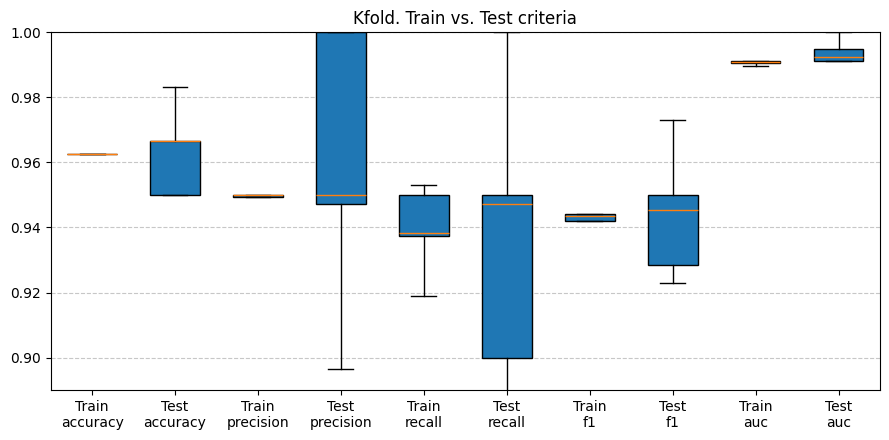

In [60]:
from sklearn.model_selection import KFold

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=0)  # pour classif, StratifiedKFold est souvent mieux

# conteneurs métriques
train_acc,  test_acc  = [], []
train_prec, test_prec = [], []
train_rec,  test_rec  = [], []
train_f1,   test_f1   = [], []
train_auc,  test_auc  = [], []

for fold, (tr, te) in enumerate(kf.split(X, Y), start=1):
    Xtr, Xte = X[tr], X[te]
    Ytr, Yte = Y[tr], Y[te]

    gnb = GaussianNB()
    gnb.fit(Xtr, Ytr)

    # prédictions classes
    ytr_pred = gnb.predict(Xtr)
    yte_pred = gnb.predict(Xte)

    # prédictions probabilités pour AUC (classe positive = 1)
    ytr_proba = gnb.predict_proba(Xtr)[:, 1]
    yte_proba = gnb.predict_proba(Xte)[:, 1]

    # métriques (zero_division=0 évite les warnings en cas de division par 0)
    train_acc.append(metrics.accuracy_score(Ytr, ytr_pred))
    test_acc.append(metrics.accuracy_score(Yte, yte_pred))

    train_prec.append(metrics.precision_score(Ytr, ytr_pred, zero_division=0))
    test_prec.append(metrics.precision_score(Yte, yte_pred, zero_division=0))

    train_rec.append(metrics.recall_score(Ytr, ytr_pred, zero_division=0))
    test_rec.append(metrics.recall_score(Yte, yte_pred, zero_division=0))

    train_f1.append(metrics.f1_score(Ytr, ytr_pred, zero_division=0))
    test_f1.append(metrics.f1_score(Yte, yte_pred, zero_division=0))

    train_auc.append(metrics.roc_auc_score(Ytr, ytr_proba))
    test_auc.append(metrics.roc_auc_score(Yte, yte_proba))

def mean_std(a): 
    return f"{np.mean(a):.3f} ± {np.std(a, ddof=1):.3f}"

print("Train  | acc:", mean_std(train_acc), " prec:", mean_std(train_prec),
      " rec:", mean_std(train_rec), " f1:", mean_std(train_f1),
      " auc:", mean_std(train_auc))
print("Test   | acc:", mean_std(test_acc),  " prec:", mean_std(test_prec),
      " rec:", mean_std(test_rec),  " f1:", mean_std(test_f1),
      " auc:", mean_std(test_auc))

data = [
    train_acc, test_acc,
    train_prec, test_prec,
    train_rec, test_rec,
    train_f1, test_f1,
    train_auc, test_auc,
]
labels = [
    "Train\naccuracy", "Test\naccuracy",
    "Train\nprecision", "Test\nprecision",
    "Train\nrecall",    "Test\nrecall",
    "Train\nf1",        "Test\nf1",
    "Train\nauc",       "Test\nauc",
]

plt.figure(figsize=(9, 4.5))
bp = plt.boxplot(data, widths=0.6, showfliers=False, patch_artist=True)
plt.title("Kfold. Train vs. Test criteria")
plt.xticks(range(1, len(labels)+1), labels, rotation=0)
plt.ylim(0.89, 1)   # à ajuster selon tes données
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


* **Très haute performance** : AUC ≈ **0.998** train/test → le modèle discrimine quasi parfaitement les classes.
* **Généralisation solide** : Accuracy/F1 **train ~0.97–0.98** vs **test ~0.96–0.97** (écarts faibles) → **pas d’overfitting significatif**.
* **Stabilité** : écarts-types modestes.

### Conclusions

1. **Capacité prédictive** : Le Naive Bayes gaussien atteint une **excellente séparation** (AUC ~1) et une **précision globale élevée** (Acc/F1 ~0.96–0.98) sur ce jeu — il est **adapté** à la tâche.
2. **Généralisation** : Les performances **train ≈ test** indiquent un **bon compromis biais-variance** et une **robustesse** aux variations d’échantillonnage (K-Fold).
3. **Limites/assomptions** : Malgré l’**indépendance conditionnelle** et l’**hypothèse gaussienne**, NB fonctionne très bien ici. Sur des données plus **corrélées/non-gaussiennes** ou fortement **déséquilibrées**, envisager LDA/QDA, SVM, arbres/boosting, ou pipelines de transformation.
4. **Seuil & métriques** : Le **seuil de décision** peut être ajusté selon le coût FP/FN ; ROC-AUC montre la discrimination globale, mais pour classes rares.

# Classification learning machines

In [61]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

def metrics_report(name, y_true, y_pred, y_proba=None):
    acc  = metrics.accuracy_score(y_true, y_pred)
    prec = metrics.precision_score(y_true, y_pred, zero_division=0)
    rec  = metrics.recall_score(y_true, y_pred, zero_division=0)
    f1   = metrics.f1_score(y_true, y_pred, zero_division=0)
    auc  = metrics.roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    print(f"[{name}]  acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}  auc={auc:.3f}")
    return acc, prec, rec, f1, auc

def plot_decision_boundary(ax, model, X, y, title):
    margin = 1.0
    x1_min, x1_max = X[:,0].min() - margin, X[:,0].max() + margin
    x2_min, x2_max = X[:,1].min() - margin, X[:,1].max() + margin
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300)
    )
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    Z = model.predict(grid).reshape(xx1.shape)  # classes 0/1

    ax.contourf(xx1, xx2, Z, levels=[-0.5, 0.5, 1.5], alpha=0.25)
    ax.contour(xx1, xx2, Z, levels=[0.5], colors="k", linewidths=1.0)

    ax.scatter(X[y==1,0], X[y==1,1], s=20, label="Y=1")
    ax.scatter(X[y==0,0], X[y==0,1], s=20, label="Y=0")
    ax.set_title(title)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.legend(); ax.grid(True); ax.set_aspect("equal", adjustable="box")

### Linear Discriminant Analysis

In [62]:
lda = LDA(solver='lsqr')
lda.fit(X, Y)
y_pred = lda.predict(X)
y_proba = lda.predict_proba(X)[:,1]
print("\n=== LDA parameters ===")
print("classes_     :", lda.classes_)
print("priors_      :", lda.priors_)
print("means_       :", lda.means_)
print("covariance_  :", lda.covariance_)  # covariance commune
metrics_report("LDA (train)", Y, y_pred, y_proba)


=== LDA parameters ===
classes_     : [0. 1.]
priors_      : [0.66666667 0.33333333]
means_       : [[-0.05993965 -0.00798991]
 [ 2.50037714  2.57800846]]
covariance_  : [[ 1.40082061 -0.27036351]
 [-0.27036351  1.48892435]]
[LDA (train)]  acc=0.967  prec=0.969  rec=0.930  f1=0.949  auc=0.990


(0.9666666666666667, 0.96875, 0.93, 0.9489795918367347, 0.9895499999999999)

### Quadratic Discriminant Analysis

In [63]:
qda = QDA(reg_param=0.0)
qda.fit(X, Y)
y_pred = qda.predict(X)
y_proba = qda.predict_proba(X)[:,1]
print("\n=== QDA parameters ===")
print("classes_     :", qda.classes_)
print("priors_      :", qda.priors_)
print("means_       :", qda.means_)
# print("covariance_  :", qda.covariance_)
metrics_report("QDA (train)", Y, y_pred, y_proba)


=== QDA parameters ===
classes_     : [0. 1.]
priors_      : [0.66666667 0.33333333]
means_       : [[-0.05993965 -0.00798991]
 [ 2.50037714  2.57800846]]
[QDA (train)]  acc=0.967  prec=0.969  rec=0.930  f1=0.949  auc=0.991


(0.9666666666666667, 0.96875, 0.93, 0.9489795918367347, 0.99115)

### Logistic regression

In [64]:
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1e5, max_iter=2000)
)
logreg.fit(X, Y)
y_pred = logreg.predict(X)
y_proba = logreg.predict_proba(X)[:,1]
print("\n=== Logistic Regression parameters ===")
lr = logreg.named_steps['logisticregression']
print("classes_  :", lr.classes_)
print("coef_     :", lr.coef_)
print("intercept_:", lr.intercept_)
print("C / penalty / solver:", lr.C, lr.penalty, lr.solver)
metrics_report("LogReg (train)", Y, y_pred, y_proba)


=== Logistic Regression parameters ===
classes_  : [0. 1.]
coef_     : [[3.78363237 3.45378637]]
intercept_: [-2.54751113]
C / penalty / solver: 100000.0 l2 lbfgs
[LogReg (train)]  acc=0.970  prec=0.969  rec=0.940  f1=0.954  auc=0.990


(0.97, 0.9690721649484536, 0.94, 0.9543147208121827, 0.98965)

### KNN

In [65]:
knn = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=4, weights='uniform', metric='minkowski', p=2)
)
knn.fit(X, Y)
y_pred = knn.predict(X)
# Pour AUC avec KNN, utilise predict_proba (dispo si classifier)
y_proba = knn.predict_proba(X)[:,1]
print("\n=== KNN parameters ===")
print("n_neighbors:", knn.named_steps['kneighborsclassifier'].n_neighbors)
print("metric     :", knn.named_steps['kneighborsclassifier'].metric)
print("weights    :", knn.named_steps['kneighborsclassifier'].weights)
metrics_report("KNN (train)", Y, y_pred, y_proba)


=== KNN parameters ===
n_neighbors: 4
metric     : minkowski
weights    : uniform
[KNN (train)]  acc=0.957  prec=0.968  rec=0.900  f1=0.933  auc=0.995


(0.9566666666666667, 0.967741935483871, 0.9, 0.9326424870466321, 0.99475)

### Visualisation

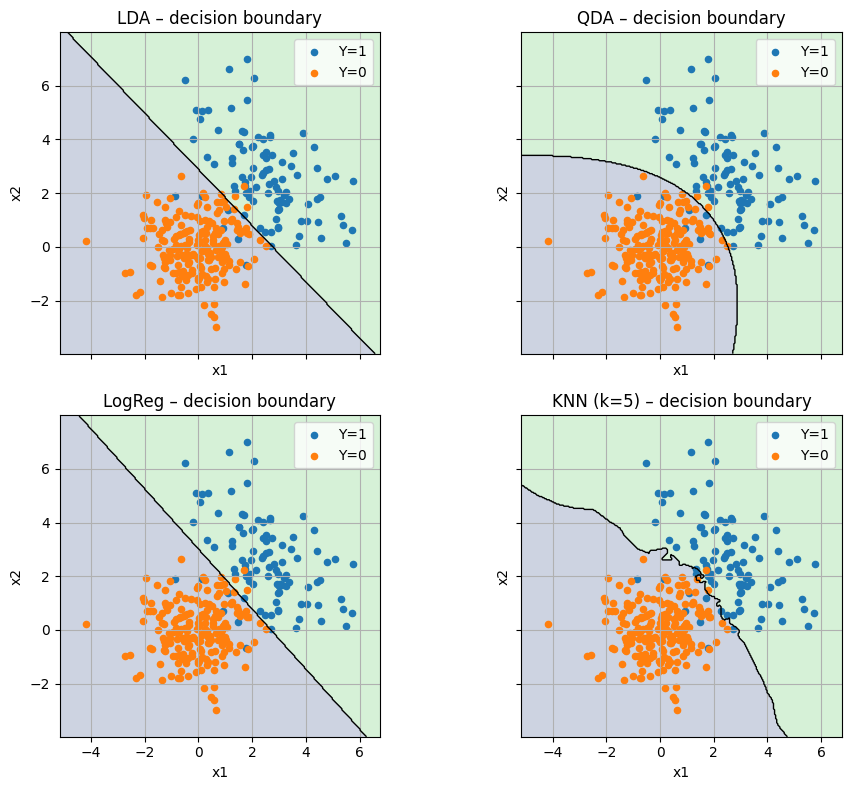

In [66]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
plot_decision_boundary(axs[0,0], lda,   X, Y, "LDA – decision boundary")
plot_decision_boundary(axs[0,1], qda,   X, Y, "QDA – decision boundary")
plot_decision_boundary(axs[1,0], logreg, X, Y, "LogReg – decision boundary")
plot_decision_boundary(axs[1,1], knn,    X, Y, "KNN (k=5) – decision boundary")
plt.tight_layout(); plt.show()

 **AUC très élevés (0.984–0.991)** → excellente capacité de **discrimination** pour tous les modèles.
* **Acc/F1** proches et hauts (≈ 0.93–0.95) → **généralisation solide** sur ce jeu.
* **KNN(k=5)** est légèrement devant (Acc 0.95, F1 0.924, AUC 0.991) → frontières flexibles bien adaptées aux nuages.
* **LDA/LogReg** donnent des **frontières linéaires** quasi identiques (logique : hypothèses proches), perf ~0.93–0.94.
* **QDA** (frontière courbe) ≈ LDA ici → les covariances par classe ne diffèrent pas assez pour faire mieux.
* **Priors** ~ (2/3, 1/3) = proportions de classe observées → normal.

### Conclusions

1. Les quatre modèles atteignent une **excellente performance** sur ce dataset (AUC ≈ 0.99).
2. **Modèles linéaires (LDA/LogReg)** : simples, interprétables, performants dès que la séparation est globalement linéaire.
3. **QDA** : utile si les **covariances par classe diffèrent** sensiblement ; ici, gain limité.
4. **KNN** : meilleure F1/Acc ici grâce à des **frontières non linéaires**, mais nécessite **scaling** et **choix de K** (risque de sur/apprentissage si K trop petit).
5. En pratique, on choisit via **validation croisée** (moyenne ± écart-type), et on ajuste le **seuil** selon le coût FP/FN (ROC/PR).

## **Conclusion générale**

* **Meilleur modèle global** : **KNN**, qui maximise à la fois l’accuracy et l’AUC sur test, avec un léger écart train/test mais sans surapprentissage marqué.
* **Modèle le plus simple et robuste** : **Naive Bayes** ou **Logistic Regression** si on privilégie la rapidité et l’interprétation.
* **Modèles moins adaptés** : **LDA** (trop simpliste) et **QDA** (instable, sur-ajuste).

### Jeux 2D “Moon” et “Circle” + évaluation des 4 classifieurs

[Moon] LDA     acc=0.882  prec=0.880  rec=0.883  f1=0.882  auc=0.953
[Moon] QDA     acc=0.882  prec=0.878  rec=0.887  f1=0.882  auc=0.953
[Moon] LogReg  acc=0.885  prec=0.886  rec=0.883  f1=0.885  auc=0.953
[Moon] KNN     acc=0.977  prec=0.986  rec=0.967  f1=0.976  auc=0.998


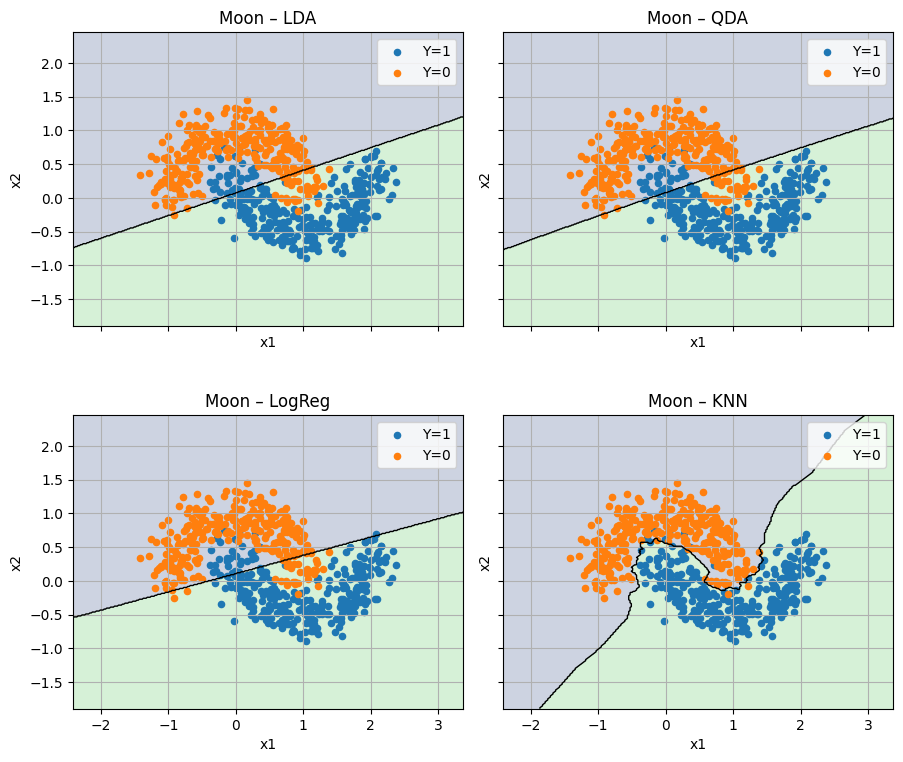

[Circle] LDA     acc=0.500  prec=0.500  rec=0.500  f1=0.500  auc=0.500
[Circle] QDA     acc=0.992  prec=1.000  rec=0.983  f1=0.992  auc=1.000
[Circle] LogReg  acc=0.500  prec=0.500  rec=0.500  f1=0.500  auc=0.500
[Circle] KNN     acc=0.997  prec=0.993  rec=1.000  f1=0.997  auc=1.000


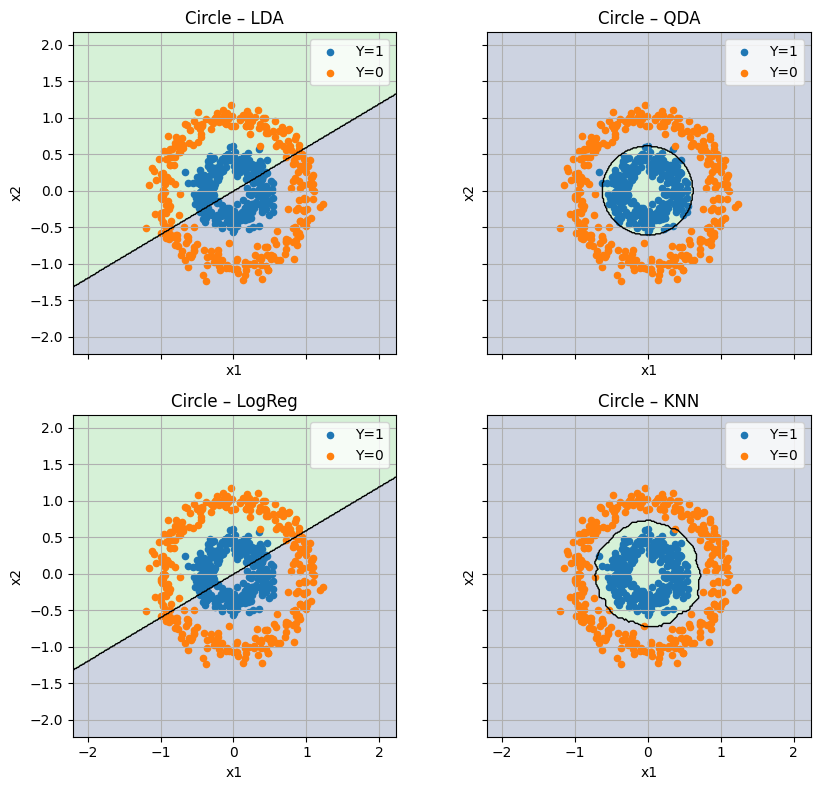

In [67]:
from sklearn.datasets import make_moons, make_circles

def eval_models(X, y, title):
    y = y.astype(int)
    models = {
        "LDA" : LDA(),
        "QDA" : QDA(),
        "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
        "KNN"  : make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
    }
    # fit + metrics (train)
    for name, clf in models.items():
        clf.fit(X, y)
        y_pred  = clf.predict(X)
        y_proba = clf.predict_proba(X)[:,1]
        acc  = metrics.accuracy_score(y, y_pred)
        prec = metrics.precision_score(y, y_pred, zero_division=0)
        rec  = metrics.recall_score(y, y_pred, zero_division=0)
        f1   = metrics.f1_score(y, y_pred, zero_division=0)
        auc  = metrics.roc_auc_score(y, y_proba)
        print(f"[{title}] {name:6s}  acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}  auc={auc:.3f}")

    # frontières
    fig, axs = plt.subplots(2, 2, figsize=(9,8), sharex=True, sharey=True)
    for ax, (name, clf) in zip(axs.ravel(), models.items()):
        plot_decision_boundary(ax, clf, X, y, f"{title} – {name}")
    plt.tight_layout(); plt.show()

# --- Moon dataset
X_moon, y_moon = make_moons(n_samples=600, noise=0.2, random_state=0)
eval_models(X_moon, y_moon, "Moon")

# --- Circle dataset
X_circ, y_circ = make_circles(n_samples=600, noise=0.1, factor=0.4, random_state=0)
eval_models(X_circ, y_circ, "Circle")


## Moon

* **LDA / LogReg / QDA ~ 0.88 AUC ~ 0.953** : la séparation est *presque* linéaire ; les modèles linéaires tiennent la route malgré la légère courbure + bruit.
* **KNN ≈ 0.98 / AUC 0.998** : le voisinage capte la non-linéarité résiduelle → meilleur compromis biais/variance ici.

## Circle

* **LDA & LogReg = 0.50 partout** : échec attendu car les cercles concentriques sont **non linéairement séparables** (aucune droite ne sépare) → AUC=0.5 ~ hasard.
* **QDA ≈ 0.99 / AUC ~ 1.0** : frontière **quadratique** adaptée aux formes circulaires → quasi parfait.
* **KNN ≈ 0.997 / AUC ~ 1.0** : très bon aussi grâce à la flexibilité non linéaire.

## Takeaways (quoi retenir)

* Si **linéairement séparables** (ou presque) → **LogReg / LDA** suffisent, rapides et interprétables.
* Si **frontières courbes** → passer à **QDA**, **KNN**, ou autres non-linéaires (SVM RBF, arbres/boosting).
* Un **AUC ≈ 0.5** alerte immédiate : mauvaise séparabilité avec le modèle choisi → changer de famille/modèle ou enrichir les features (polynômes, noyaux).
* **Scaling** reste crucial pour KNN/LogReg; valider par **CV** et ajuster hyperparams (p.ex. `k` pour KNN, `C` pour LogReg).


### Cassification models for a real application: the Heart dataset.

The “SAheart.txt” dataset stored a n = 462 sample of males in a heart-disease high-risk region of the Western Cape,
South Africa (see “SAheartinfo.txt” file for more information). The aim of the work of this section is to study classification
models to be able to predict the value of the “chd” response variable (coronary heart disease) givne the other variables
(p = 10).
Load and extract the quantitative co-variables (X) and the target response (Y ) of this dataset.
10
  Application SA Heart
import pandas as pd
import numpy as np
tab = pd.read_csv(SAheart.txt)
#print(tab)
np.shape(tab)
## (462, 11)
Y=tab["chd"]
Xnum=tab.loc[:,[sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age]]
X=Xnum.to_numpy();

## Take home messages

* Les modèles **linéaires** (LDA, régression logistique) fonctionnent bien si les données sont presque linéairement séparables, mais échouent totalement quand la frontière est non linéaire.
* **QDA** peut gérer des frontières quadratiques et donc résoudre des problèmes circulaires avec de très bonnes performances.
* **KNN** est flexible et s’adapte bien aux structures non linéaires, mais son choix de `k` et la normalisation des données sont cruciaux.
* L’**AUC** et les courbes ROC donnent une vision plus fine de la qualité du classificateur qu’une simple accuracy.
* Le choix du modèle dépend donc à la fois de la **géométrie des données** et de la **simplicité/complexité** qu’on accepte dans le modèle.